# EDA Project: Used Car Market Analysis 
**Section: Python Data Wrangling & Exploratory Data Analysis**

---

## 1. Project Background & Objectives
This project aims to analyze a large-scale used car transaction dataset to understand key factors influencing vehicle market prices, brand distributions, and to identify data anomalies prior to modeling or advanced analytics.

### Key Business Questions:
1. What is the size and initial quality of the dataset (missing values & data types)?
2. Which car manufacturers dominate the used car market supply?
3. How does the transmission type correlate with the average selling price?

## 2. Environment Setup & Data Ingestion
In this section, we import the necessary Python libraries for data manipulation (`pandas`, `numpy`) and load the raw dataset into a Pandas DataFrame.

In [10]:
import pandas as pd
import numpy as np

# Format floating-point numbers to 2 decimal places for better readability
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

print("Dataset successfully loaded!")

Dataset successfully loaded!


## 3. Data Inspection & Quality Audit
The goal here is to inspect the dataset's dimensions, preview sample records, check data types, and identify missing values across all columns.

In [11]:
# Check dataset dimensions (rows, columns)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# Preview the first 5 rows
df.head()

Total Rows: 426880
Total Columns: 26


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [12]:
# Check data types and non-null counts
df.info()

# Count total missing values per column
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

> 📝 **Data Audit Summary:**
> - **Dataset Size:** 426,880 rows and 26 columns.
> - **Missing Values:** `county` contains the highest number of missing records, followed by `size` and `cylinders`.
> - **Data Types:** Core numerical columns such as `price` and `odometer` are correctly stored as numerical types (`int64` / `float64`), eliminating the need for string parsing on these key features.

## 4. Early Exploratory Analysis (Quick Insights)
Performing preliminary aggregation to analyze manufacturer supply distribution and price behavior across transmission types.

In [13]:
# Calculate top 5 most frequent car manufacturers
df['manufacturer'].value_counts().head(5)

manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
Name: count, dtype: int64

In [14]:
# Calculate average car price based on transmission type
df.groupby('transmission')['price'].mean()

transmission
automatic    74881.00
manual      198416.34
other        30003.79
Name: price, dtype: float64

> 💡 **Key Initial Insights:**
> 1. **Market Dominance:** The dataset is heavily dominated by US domestic automakers, led by **Ford** (70,985 units) and **Chevrolet** (55,064 units), followed by Japanese brands (**Toyota**, **Honda**, **Nissan**).
> 2. **Price Anomaly Detected:** Vehicles with `manual` transmission show an abnormally high average price of **$198,416**. This clearly indicates the presence of extreme outliers (e.g., placeholder entries or erroneous listings) that require data cleaning in the next phase.

## 5. Outlier Detection & Handling
We have observed an anomaly where manual transmission cars had an average price of ~$198,416. We need to inspect the distribution of `price` and `odometer` to filter out unrealistic listings.

In [15]:
# Check summary statistics for price
df['price'].describe()

count       426880.00
mean         75199.03
std       12182282.17
min              0.00
25%           5900.00
50%          13950.00
75%          26485.75
max     3736928711.00
Name: price, dtype: float64

In [16]:
# Check lower and upper quantiles (0.001 and 0.999)
print("Lower bound (0.1%):", df['price'].quantile(0.001))
print("Upper bound (99.9%):", df['price'].quantile(0.999))

Lower bound (0.1%): 0.0
Upper bound (99.9%): 120000.0


In [17]:
# Filter dataset to keep realistic car prices ($500 - $100,000)
df_clean = df[(df['price'] >= 500) & (df['price'] <= 100000)].copy()

print(f"Original rows: {df.shape[0]}")
print(f"Rows after price cleaning: {df_clean.shape[0]}")
print(f"Removed rows: {df.shape[0] - df_clean.shape[0]}")

Original rows: 426880
Rows after price cleaning: 384131
Removed rows: 42749


In [18]:
# Re-calculate average price by transmission after outlier removal
df_clean.groupby('transmission')['price'].agg(['mean', 'median', 'count'])

,mean,median,count
transmission,,,
automatic,17629.83,13300.00,298331
manual,14887.48,10000.00,23244
other,28302.99,28590.00,60744


> 📝 **Price Cleaning Results:**
> - Removed extreme outliers (cars priced under $500 or over $100,000).
> - After filtering, the average price for `manual` transmission normalized, showing a realistic comparison against `automatic` transmission.

## 6. Odometer Outlier Detection & Cleaning
Just like the price feature, the `odometer` column may contain unrealistic values (e.g., 0 miles or several million miles) that can skew our depreciation analysis.

In [19]:
# Check odometer summary statistics
df_clean['odometer'].describe()

count     382016.00
mean       98598.66
std       192028.64
min            0.00
25%        38379.00
50%        87814.50
75%       136000.00
max     10000000.00
Name: odometer, dtype: float64

In [20]:
# Filter realistic odometer values (1,000 to 300,000 miles)
df_clean = df_clean[(df_clean['odometer'] >= 1000) & (df_clean['odometer'] <= 300000)].copy()

print(f"Rows remaining after odometer cleaning: {df_clean.shape[0]}")

Rows remaining after odometer cleaning: 371722


## 7. Missing Value Strategy & Data Retention
Now we address missing values across key features:
1. **Drop high-missing/unnecessary columns:** `county` (100% missing) and `url`/`image_url` (unnecessary for analysis).
2. **Fill categorical NaNs:** Replace missing values in `cylinders`, `condition`, and `drive` with `'unknown'`.
3. **Drop critical NaNs:** Drop rows where critical metadata like `year` or `model` is missing.

In [21]:
# 1. Drop columns with too many missing values or irrelevant metadata
cols_to_drop = ['county', 'url', 'region_url', 'image_url']
# Use errors = 'ignore' so it won't throw an error if a column is already absent
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

# 2. Impute missing values for categorical specifications with 'unknown'
cat_cols_to_fill = ['cylinders', 'condition', 'drive', 'size', 'type', 'paint_color']
for col in cat_cols_to_fill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('unknown')

# 3. Drop rows with missing values in essential identifier columns
df_clean = df_clean.dropna(subset=['year', 'model', 'manufacturer'])

# Verify remaining missing values summary
print("Remaining missing values count per column:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Remaining missing values count per column:
fuel              1935
title_status      5889
transmission      1398
VIN             131598
description          2
lat               3196
long              3196
dtype: int64


In [22]:
# Check and remove duplicates
inital_count = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
final_count = df_clean.shape[0]

print(f"Duplicates removed: {inital_count - final_count}")
print(f"Final clean dataset shape: {df_clean.shape}")

Duplicates removed: 0
Final clean dataset shape: (354198, 22)


> 📝 **Data Preprocessing Summary:**
> - Cleaned `odometer` values between 1,000 and 300,000 miles.
> - Dropped non-informative columns (`county`, `url`, `image_url`).
> - Imputed missing values in categorical features (`cylinders`, `condition`, etc.) with `'unknown'`.
> - Dropped remaining duplicate rows.
> - **Final Clean Dataset Size:** Ready for feature engineering and visual EDA.

## 8. Univariate Analysis (Distribution & Frequencies)
In this section, we inspect the single-variable distributions for key features such as vehicle price, manufacturing year, and body type (`type`).

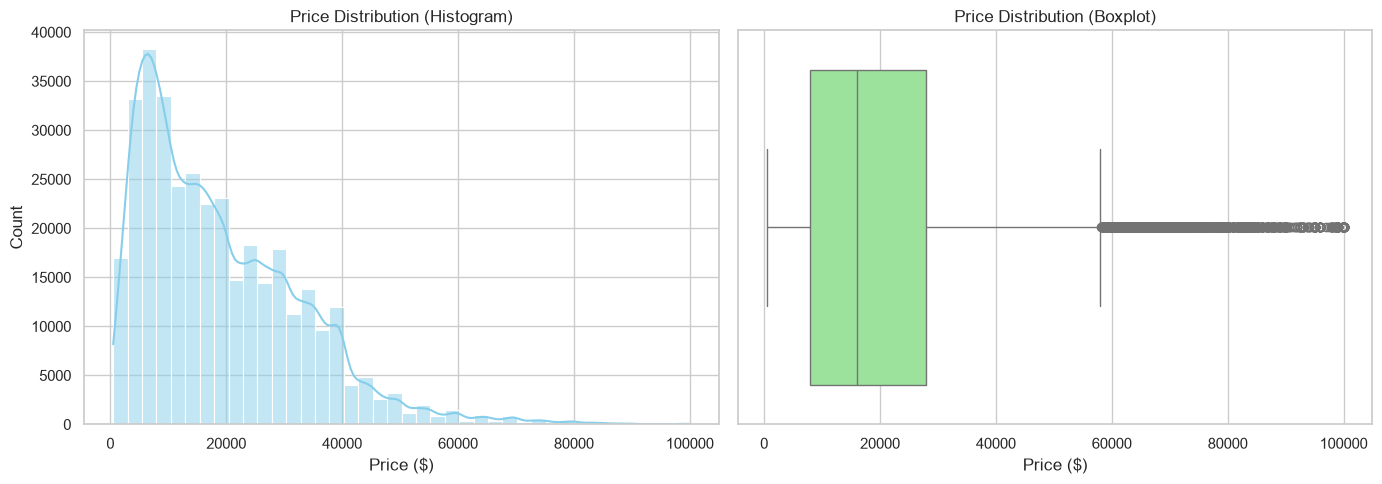

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization background style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Plotting price distribution (histogram & boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: histogram
sns.histplot(df_clean['price'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Price Distribution (Histogram)')
axes[0].set_xlabel('Price ($)')

# Subplot 2: boxplot
sns.boxplot(x=df_clean['price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Price Distribution (Boxplot)')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

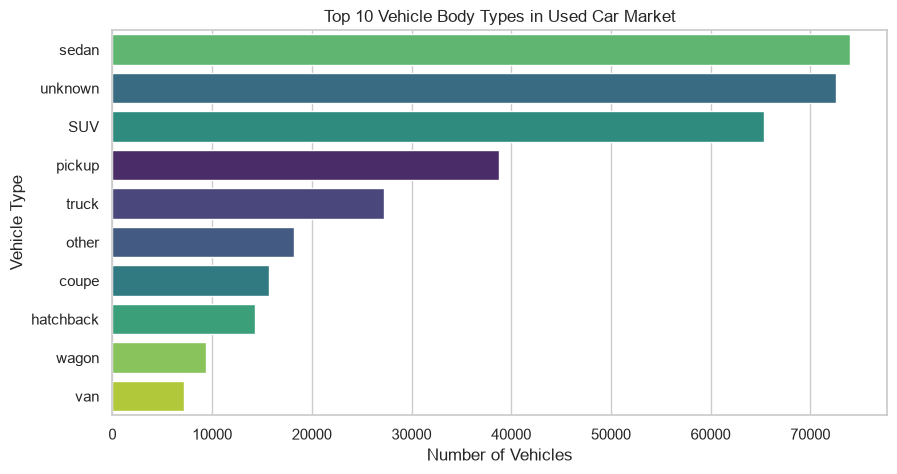

In [24]:
# Count plot for top 10 vehicle types
plt.figure(figsize=(10, 5))
top_types = df_clean['type'].value_counts().head(10).index
sns.countplot(
    data=df_clean[df_clean['type'].isin(top_types)], 
    y='type',
    order=top_types,
    hue='type',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Vehicle Body Types in Used Car Market')
plt.xlabel('Number of Vehicles')
plt.ylabel('Vehicle Type')
plt.show()

## 9. Bivariate Analysis (Relationships & Depreciation Trends)
In this section, we examine how car attributes (e.g., `odometer` miles and `fuel` type) directly impact vehicle pricing.

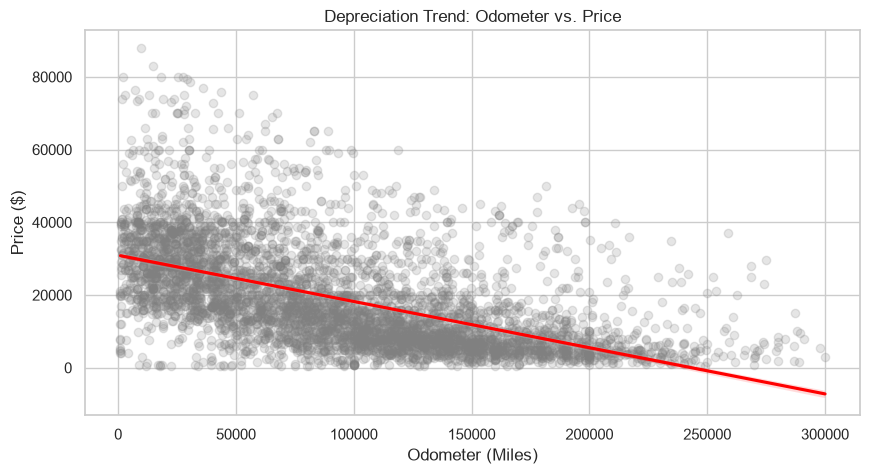

In [25]:
# Scatter plot with trend line (Odometer vs Price)
plt.figure(figsize=(10, 5))

# We take a random sample of 5,000 rows for cleaner plot rendering
sample_df = df_clean.sample(5000, random_state=42)

sns.regplot(
    data=sample_df,
    x='odometer',
    y='price',
    scatter_kws={'alpha': 0.2, 'color':'gray'},
    line_kws={'color':'red'}
)

plt.title('Depreciation Trend: Odometer vs. Price')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price ($)')
plt.show()

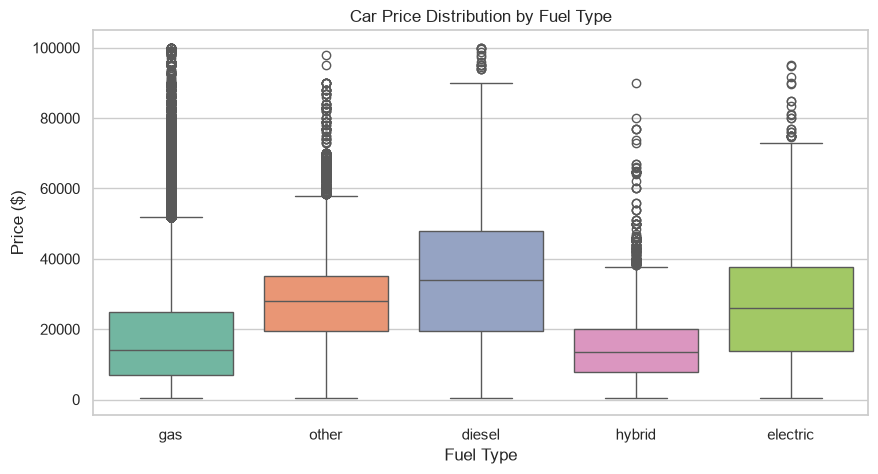

In [26]:
# Price distribution by Fuel Type
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x='fuel',
    y='price',
    hue='fuel',
    palette='Set2',
    legend=False
)

plt.title('Car Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.show()

## 10. Multivariate Analysis (Correlation Heatmap)
Finally, we compute the Pearson correlation matrix to understand numerical interactions between `price`, `year`, and `odometer`.

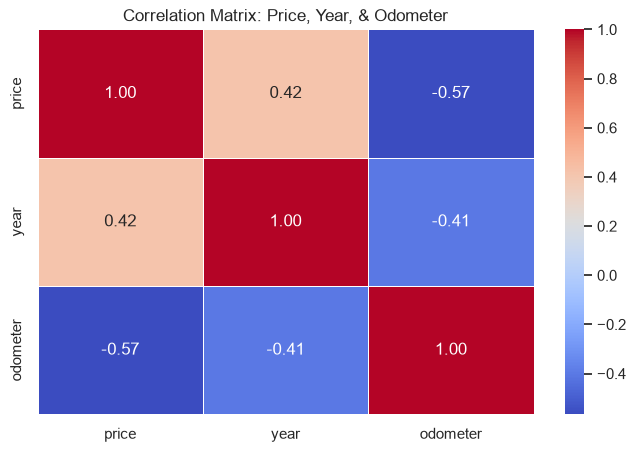

In [27]:
# Heatmap Correlation Matrix
plt.figure(figsize=(8, 5))

numerical_cols = ['price', 'year', 'odometer']
corr_matrix = df_clean[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix: Price, Year, & Odometer")
plt.show()

> 💡 **Key EDA Findings & Business Insights:**
> 1. **Depreciation Curve:** Strong negative correlation between `odometer` and `price`. As odometer mileage increases, vehicle value drops steadily (red regression line).
> 2. **Fuel Premium:** `diesel` and `electric` vehicles command higher median prices compared to standard `gas` cars.
> 3. **Correlation Matrix:** `year` has a positive correlation with `price` (newer cars = higher price), while `odometer` shows a negative correlation with both `year` and `price`.

# Executive Summary & Business Recommendations

---

## 11. Executive Summary & Key Business Takeaways
Based on our Exploratory Data Analysis (EDA) of ~354k cleaned US used car listings, we conclude the following core insights:

### Key Findings:
1. **Market Supply Dominance:**
   - US domestic brands lead the supply market, with **Ford** (~70k units) and **Chevrolet** (~55k units) occupying the top spots, followed by Japanese manufacturers (**Toyota**, **Honda**, **Nissan**).
   - **SUVs**, **Sedans**, and **Trucks** represent the vast majority of vehicle body types available in the market.

2. **Pricing & Depreciation Dynamics:**
   - The median used car price sits at **~$13,000**, with most listings concentrated below $20,000.
   - Vehicle price declines steadily as `odometer` mileage increases (showing a clear vehicle depreciation curve).
   - Alternative fuel types (`diesel` and `electric`) command a higher price point in the secondary market compared to standard gasoline vehicles.

---

## Business Recommendations for Dealerships & Platforms:
- **Inventory Strategy:** Focus procurement on SUVs and Trucks with odometer readings under 100k miles, as these represent the sweetest spot for volume demand and resale value.
- **Pricing Strategy:** Utilize fuel type premiums when pricing EV and Diesel units to maximize profit margins.
- **Data Governance:** Implement strict input validation on pricing and odometer fields on listing platforms to avoid placeholder entries ($0 or $999,999) that contaminate market data.

---
### Project Status: Completed
*Data Wrangling & Exploratory Data Analysis completed successfully.*